# 🧪 Práctica 3: Exploración de Estructuras Galácticas con Gaia y SDSS

## 🧭 Instrucciones sobre el uso de SQL en astrofísica

En este notebook utilizamos consultas SQL (Structured Query Language) para acceder a catálogos astronómicos públicos como Gaia y SDSS. Las consultas SQL permiten seleccionar y filtrar información de bases de datos mediante condiciones específicas como magnitudes, posiciones, paralaje, redshift, etc.

Ejemplo básico de estructura SQL:

```sql
SELECT columna1, columna2
FROM nombre_tabla
WHERE condición
```

En este notebook, verás cómo se construyen estos `query` como cadenas de texto que luego son ejecutadas por librerías como `astroquery`.


In [1]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.4/999.4 kB 16.5 MB/s eta 0:00:00


### ✨ Gaia 1: Identificando el Cúmulo de Sequoia

FSR 1758 (también conocido como Cúmulo de la Secuoya) es un cúmulo globular grande y brillante, pero muy oscurecido, perteneciente a la Vía Láctea. Se encuentra a una distancia de unos 11,5 kpc del Sol y a unos 3,7 kpc del centro de la galaxia. En este ejercicio queremos estudiar una estructura fósil de este cúmmulo.

📍 Coordenadas aproximadas del centro del cúmulo:
- RA	17h 31m 12s (≈ 262.8 °)
- Dec -39° 48' 30″ (≈ -39.8 )

🧩 Para ello, generarás un `query` a Gaia DR3 que recupere estrellas con baja paralaje (lejanas) y movimientos propios moderados.

🎯 Objetivos: visualizar la distribución espacial (RA vs DEC) y de movimientos propios (PMRA vs PMDEC) y detectar la agrupación asociada a Sequoia.

1. Elabore un "query" para el cúmulo, solicite estrellas con bajo paralaje (entre mas < 0.1). Debe pedir las coordenadas ra y dec para acotar la región y solicitar las estrellas, use regiones pequeñas menores a un grado para encontrar el cúmulo. Limite la consulta a estrellas más brillantes que 22 magnitudes en la banda g.

2. Visualice la distribución espacial encontrada con la función de matplotlib.pyplot.scatter en RA y DEC.

3. Visualice la distribución de movimientos propios de las estrellas encontradas con la función de matplotlib.pyplot.scatter en pmra y pmdec.

4. Genere un diagrama Color-Magnitud (bp_rp vs mag_g).

5. ¿Qué observa? ¿Cuantas estrellas pertenecen o usted crea que pertenezcan al cúmulo? ¿Qué metodo usaría para identificar la pertenencia al cúmulo con los parametros que se pueden obtener de GAIA


In [2]:
from astroquery.gaia import Gaia
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

query ='''
SELECT
source_id, ra, dec, l, b, parallax, bp_rp, pmra, pmdec, phot_g_mean_mag, teff_gspphot
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 263.4 AND 263.8 AND dec BETWEEN -39.3 AND -38.8
AND parallax < 0.1
AND phot_g_mean_mag < 22
'''

job = Gaia.launch_job_async(query)
df = job.get_results().to_pandas()
df.head()

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


,source_id,ra,dec,l,b,parallax,bp_rp,pmra,pmdec,phot_g_mean_mag,teff_gspphot
0,5961705535070971776,263.400014,-39.219434,349.963842,-3.360307,-0.274710,2.150209,-0.521333,-1.201291,20.440451,NaN
1,5961804456735579264,263.400031,-39.032594,350.121161,-3.259101,-0.158420,1.819878,-4.170353,-5.811973,20.079575,NaN
2,5961802734455983360,263.400044,-39.151440,350.021107,-3.323495,0.011246,3.195551,-0.910453,-3.976629,16.236969,4751.860352
3,5961705741225916928,263.400072,-39.201049,349.979348,-3.350386,-0.392035,2.519039,1.710032,-4.010515,19.605309,NaN
4,5961705844308068608,263.400093,-39.198853,349.981206,-3.349211,-0.711108,2.240429,-0.388170,-9.336640,20.099377,NaN


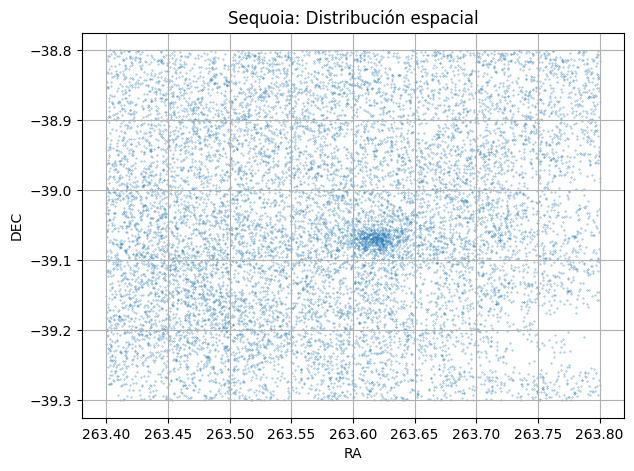

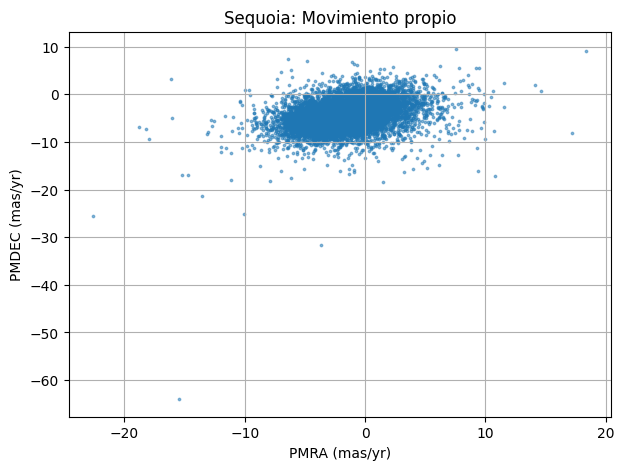

In [3]:
# Gráfico de posiciones
plt.figure(figsize=(7, 5))
plt.scatter(df['ra'], df['dec'], s=0.1, alpha=0.7)
plt.xlabel("RA")
plt.ylabel("DEC")
plt.title("Sequoia: Distribución espacial")
plt.grid(True)
plt.show()
plt.close()
# Gráfico de movimientos propios
plt.figure(figsize=(7, 5))
plt.scatter(df['pmra'], df['pmdec'], s=3, alpha=0.5)
plt.xlabel("PMRA (mas/yr)")
plt.ylabel("PMDEC (mas/yr)")
plt.title("Sequoia: Movimiento propio")
plt.grid(True)
plt.show()
plt.close()

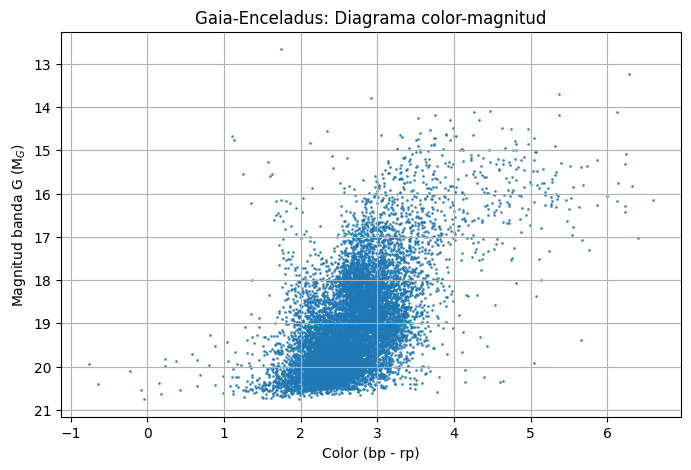

In [4]:
# Gráfico de Diagrama H-R
plt.figure(figsize=(8,5))
plt.scatter(df["bp_rp"], df["phot_g_mean_mag"], s=1, alpha=0.75)
plt.gca().invert_yaxis()
plt.xlabel("Color (bp - rp)")
plt.ylabel(r"Magnitud banda G (M$_G$)")
plt.title("Gaia-Enceladus: Diagrama color-magnitud")
plt.grid(True)
plt.show()

### ✨ Gaia 2: Explorando el cúmulo estelar de Pegaso

En este ejercicio estudiaremos el **cúmulo estelar abierto de Pegaso** (*Pegasus Cluster*, también conocido como **Peg OB1**). Fue descubierto por Jean-Dominique Maraldi en 1746 e incluido en el catálogo de objetos similares a cometas de Charles Messier en 1764. Messier 15 (M15), también reportado como NGC 7078, es un cúmulo globular situado en la constelación de Pegaso. Con una edad estimada de 12000 millones de años, es uno de los cúmulos globulares más antiguos conocidos y una reliquia de los primeros años de la Vía Láctea. Se encuentra a $\approx$ 11 kpc de la Tierra.

📍 Coordenadas aproximadas del centro del cúmulo:
- RA ≈ 322.5°
- Dec ≈ +12.2°

🎯 Objetivos: obtener estrellas cercanas al cúmulo con paralaje consistente (distancia similar), y analizar su distribución en el espacio de movimientos propios y su Diagrama H-R. \\

1. Elabore un "query" para el cúmulo, solicite las coordenadas de declinación y la ascensión recta en un area de 5 grados cuadrados alrededor del centro. El paralaje debe ser consistente, puede limitar la busqueda si lo considera pertinente. Establezca límites en RA y DEC donde se restrinja el cúmulo en un area de 0.5 grados cuadrados.
Hint: puede ayudarse de un scatter plot (matplotlib.pyploy.scatter) para visualizar mejor la distribución.

2. Elabore un segundo "query" para obtener el cúmulo dentro de los límites que determino en el paso anterior, donde solicite el parametro de color "bp_rp" y las estrellas *más brillantes* que 24 magnitudes en la banda g.

3. Genere un diagrama Color-Magnitud (bp_rp vs mag_g). ¿Qué observa? ¿Cuantas estrellas pertenecen o usted crea que pertenezcan al cúmulo? ¿Qué metodo usaría para identificar la pertenencia al cúmulo con los parametros que se pueden obtener de GAIA ?




In [5]:
# Query Gaia: estrellas con paralaje baja
query ='''
SELECT
source_id, ra, dec, l, b, parallax, bp_rp, pmra, pmdec, radial_velocity, phot_g_mean_mag, teff_gspphot
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 322 AND 323 AND dec BETWEEN 11.5 AND 12.5
AND parallax BETWEEN 0.1 AND 0.2
AND phot_g_mean_mag < 24
'''

job = Gaia.launch_job_async(query)
df = job.get_results().to_pandas()

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


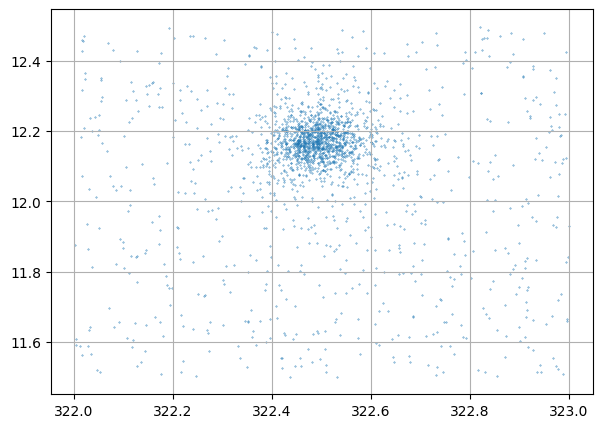

In [6]:
# Visualización de movimientos propios
plt.figure(figsize=(7, 5))
plt.scatter(df['ra'], df['dec'], s=0.1)
plt.grid(True)
plt.show()

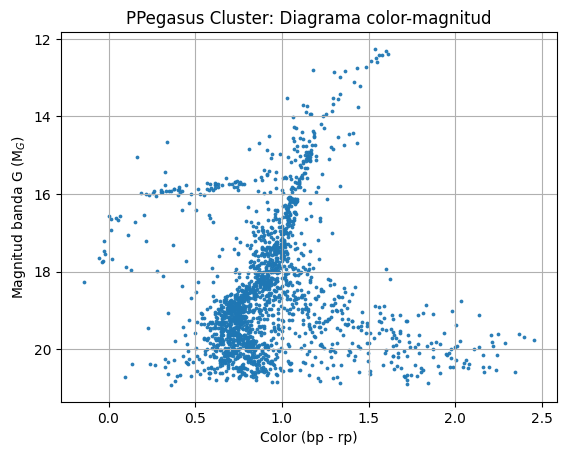

In [7]:
# Visualización de movimientos propios
plt.figure()
plt.scatter(df['bp_rp'], df['phot_g_mean_mag'], s=3, alpha=0.9)
plt.gca().invert_yaxis()
plt.xlabel("Color (bp - rp)")
plt.ylabel(r"Magnitud banda G (M$_G$)")
plt.title("PPegasus Cluster: Diagrama color-magnitud")
plt.grid(True)
plt.show()

### 🌀 SDSS 1: El Quinteto de Stephan — ¿Grupo real o ilusión?

Investigaremos si las galaxias del famoso **Quinteto de Stephan** están físicamente relacionadas o solo proyectadas.

📍 Coordenadas del centro:
- RA ≈ 339.0°
- Dec ≈ 33.96°

🎯 Objetivo: obtener redshift de galaxias en esa zona para ver si están a distancias similares.


1. Construcción de una consulta inicial. Elabore un "query" para explorar la región del cielo donde se encuentra el Quinteto de Stephan, un conjunto aparente de galaxias. Solicite las coordenadas de RA y Dec de objetos tipo galaxia (type = 3) dentro de una área de 5 arcmin de radio alrededor del centro del grupo. Establezca límites en RA y Dec que restrinjan el grupo visualmente a un área de aproximadamente 0.5 grados cuadrados o menos. Incluya únicamente galaxias más brillantes que 20 magnitudes en la banda r.

2. Elabore un segundo "query" para obtener el redshift del grupo dentro de los límites determinados en el paso anterior, donde solicite las magnitudes de las galaxias.

3. Genere un diagrama color-magnitud (g - r vs r) usando los datos del segundo query. ¿Qué observa en la distribución de color y magnitud? ¿Puede distinguir una secuencia de galaxias rojas? ¿Cuántas galaxias cree que podrían pertenecer realmente al Quinteto?

4. ¿Cúales son los redshift z de estas galaxias, podria confirmar la membresía al grupo ? ¿Son un grupo real o es efecto de proyección?

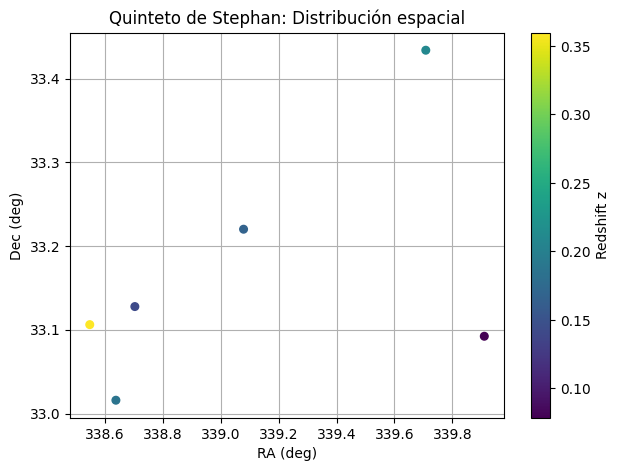

In [23]:
from astroquery.sdss import SDSS
query = """
SELECT
  s.specobjid, s.z, p.objid, p.ra, p.dec, p.r, p.g, p.i
FROM SpecObj AS s
JOIN PhotoObj AS p ON s.bestobjid = p.objid
WHERE s.z > 0
  AND p.type = 3        -- galaxias
  AND p.ra BETWEEN 338 AND 340
  AND p.dec BETWEEN 33 AND 35
  AND p.r < 18
"""
# Ejecutar la consulta
results = SDSS.query_sql(query)

# Convertir resultados a pandas DataFrame
df = results.to_pandas()
df.head()
# Visualización de movimientos propios
plt.figure(figsize=(7, 5))
plt.scatter(df['ra'], df['dec'], s=30, c=df['z'])
plt.colorbar(label="Redshift z")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.title("Quinteto de Stephan: Distribución espacial")
plt.grid(True)
plt.show()

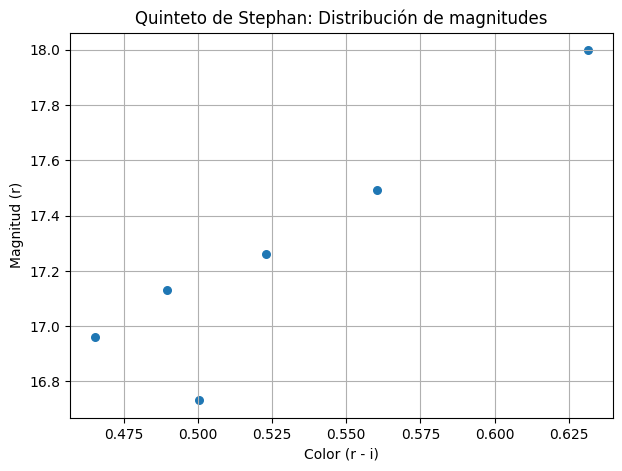

In [24]:
# Visualización de magnitudes
plt.figure(figsize=(7, 5))
plt.scatter(df['r']-df['i'], df['r'], s=30)
plt.xlabel("Color (r - i)")
plt.ylabel("Magnitud (r)")
plt.title("Quinteto de Stephan: Distribución de magnitudes")
plt.grid(True)
plt.show()

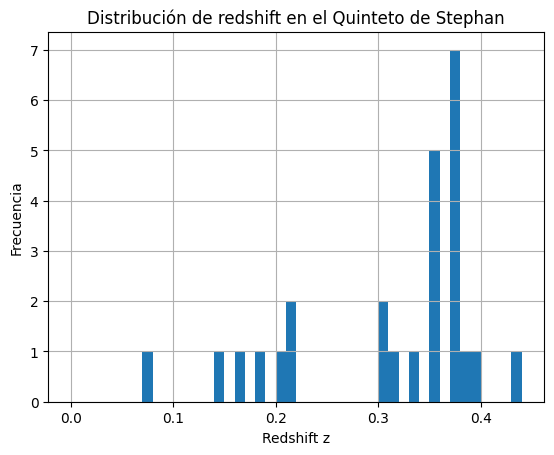

In [18]:
plt.hist(df['z'],bins=np.arange(0,0.45,0.01))
plt.xlabel("Redshift z")
plt.ylabel("Frecuencia")
plt.title("Distribución de redshift en el Quinteto de Stephan")
plt.grid(True)

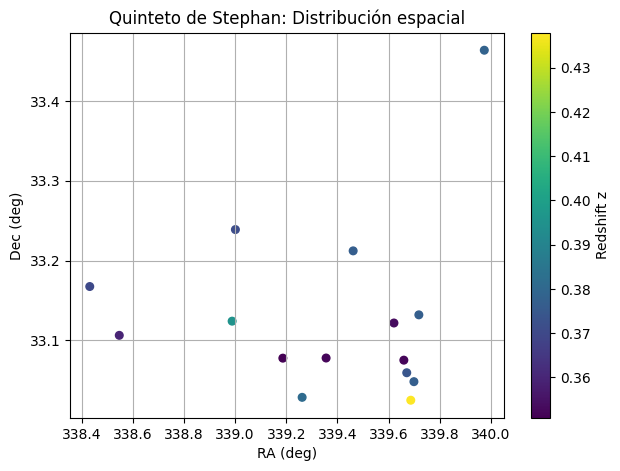

In [22]:
# Visualización de movimientos propios
plt.figure(figsize=(7, 5))
plt.scatter(df['ra'][df['z']>0.35], df['dec'][df['z']>0.35], s=30, c=df['z'][df['z']>0.35])
plt.colorbar(label="Redshift z")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.title("Quinteto de Stephan: Distribución espacial")
plt.grid(True)
plt.show()

### 🌀 SDSS: Explorando el cúmulo de Coma

En este ejercicio investigaremos el **cúmulo de Coma**, una densa agrupación de galaxias situada en el cúmulo local, a aproximadamente 100 Mpc de distancia.

📍 Coordenadas aproximadas del centro del cúmulo de Coma:
- RA ≈ 194.95°
- Dec ≈ 27.98°

🎯 Objetivo: obtener galaxias con datos espectroscópicos y redshift en el rango `0.015 < z < 0.035`, para analizar su distribución espacial.


1. Elabore un "query" para explorar la región del cielo donde se encuentra el cúmulo de Coma. Solicite las coordenadas de ascensión recta (RA) y declinación (Dec) de objetos tipo galaxia (type = 3) dentro de un área de 5 grados de radio alrededor del centro del cúmulo. Establezca límites en RA y Dec que restrinjan el cúmulo visualmente en un área. \\

Hint: puede ayudarse de un scatter plot (matplotlib.pyplot.scatter) para visualizar la distribución espacial y determinar los límites adecuados.

2. Genere un diagrama color-magnitud (g - r vs r) usando los datos del "query". Solicitelos si no la hecho originalmente. ¿Qué observa en la distribución de color y magnitud? ¿Puede distinguir una secuencia de galaxias rojas? ¿Cuántas galaxias cree que podrían pertenecer realmente al Cúmulo?

3. ¿Cúales son los redshift (z) de estas galaxias, podria confirmar la membresía al con z ? ¿Son un cúmulo real o es efecto de proyección?


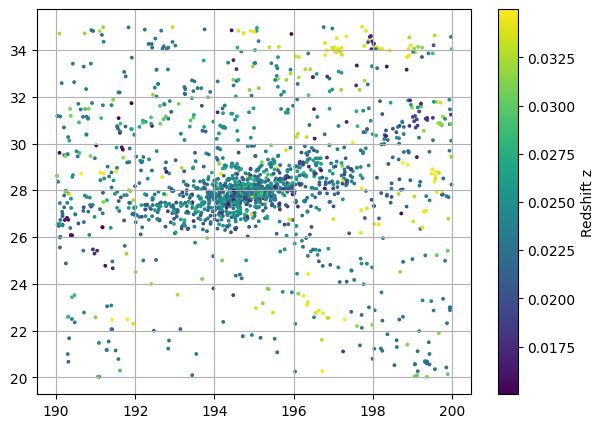

In [ ]:
query = """
SELECT
  s.specobjid, s.z, p.objid, p.l, p.b, p.ra, p.dec, p.r, p.g, p.i
FROM SpecObj AS s
JOIN PhotoObj AS p ON s.bestobjid = p.objid
WHERE s.z BETWEEN 0.015 AND 0.035
  AND p.type = 3        -- galaxias
  AND p.ra BETWEEN 190 AND 200
  AND p.dec BETWEEN 20 AND 35

"""
# Ejecutar la consulta
results = SDSS.query_sql(query)

# Convertir resultados a pandas DataFrame
df = results.to_pandas()
df.head()
plt.figure(figsize=(7,5))
plt.scatter(df['ra'], df['dec'],c=df['z'] ,s=3 )
plt.colorbar(label="Redshift z")
plt.grid(True)
plt.show()

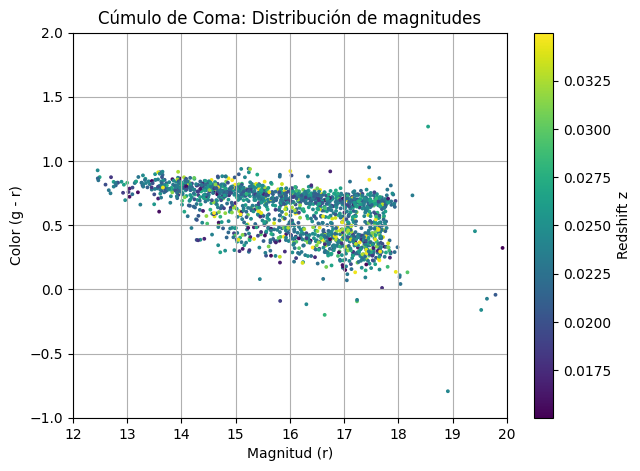

In [ ]:
#Diagrama color magnitud
plt.figure(figsize=(7,5))
plt.scatter( df['r'], df['g']-df['r'],c=df['z'] ,s=3 )
plt.ylabel("Color (g - r)")
plt.xlabel("Magnitud (r)")
plt.xlim(12,20)
plt.ylim(-1,2)
plt.title("Cúmulo de Coma: Distribución de magnitudes")
plt.colorbar(label="Redshift z")
plt.grid(True)
plt.show()

(array([ 60.,  84., 192., 376., 449., 256.,  91.,  46.,  78.,  98.]),
 array([0.01503399, 0.01702977, 0.01902555, 0.02102133, 0.02301711,
        0.02501289, 0.02700867, 0.02900445, 0.03100023, 0.03299601,
        0.03499179]),
 <BarContainer object of 10 artists>)

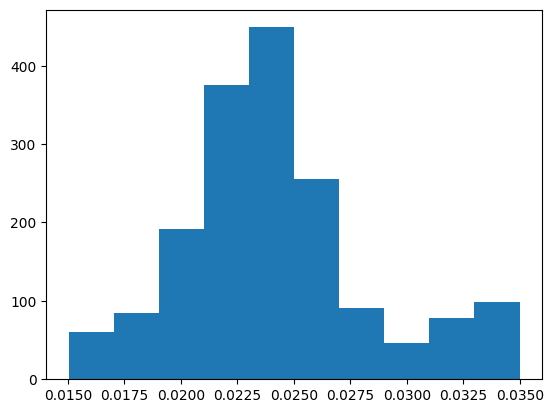

In [ ]:
plt.hist(df['z'])